# Insurance Risk Analytics

## Task 3: A/B Hypothesis Testing

### Business Objective

The objective of this analysis is to determine whether differences in insurance risk and profitability across customer segments are statistically significant. The findings will provide evidence to support data-driven pricing strategies and risk segmentation decisions.

## Why Hypothesis Testing?

This analysis evaluates whether observed differences in insurance risk and profitability across customer segments are statistically significant. The results provide evidence to support or reject potential pricing and risk segmentation strategies, helping ensure that business decisions are based on data rather than assumptions.

In [1]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind

import sys
sys.path.append("../")
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_loader import load_data, preprocess_data

from src.hypothesis_tests import (
    calculate_claim_frequency,
    calculate_claim_severity,
    calculate_margin,
    chi_square_test,
    independent_t_test,
    create_results_table,
    run_hypothesis_test,
    plot_claim_frequency,
    plot_margin,
)

from src.config import DATA_PATH

In [2]:
df = load_data(DATA_PATH)

df = preprocess_data(df)

### Prepare KPIs

In [3]:
claim_frequency_df = calculate_claim_frequency(df)

claim_severity_df = calculate_claim_severity(df)

margin_df = calculate_margin(df)

## Hypothesis 1

### Null Hypothesis (H₀)

There is no significant difference in claim frequency between Gauteng and Western Cape.

### Alternative Hypothesis (H₁)

There is a significant difference in claim frequency between Gauteng and Western Cape.

### Statistical Test

Chi-Square Test of Independence

### Group A

Gauteng

### Group B

Western Cape

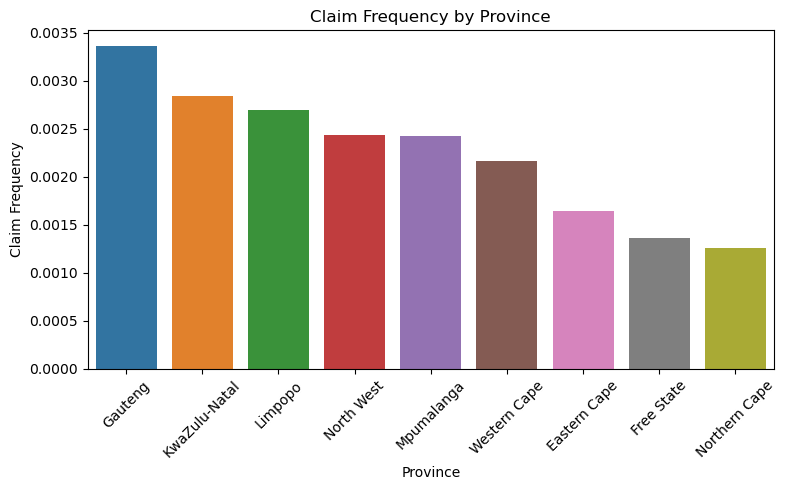

In [4]:
result1 = run_hypothesis_test(
    df=claim_frequency_df,
    test_name="Risk Difference Across Provinces",
    test_type="chi-square",
    group_column="Province",
    group_a="Gauteng",
    group_b="Western Cape",
    outcome_column="ClaimOccurred",
)
plot_claim_frequency(
    claim_frequency_df,
    "Province",
)

## Hypothesis 2

### Null Hypothesis (H₀)

There is no significant difference in claim frequency between Postal Code 2000 and Postal Code 122.

In [5]:
result2 = run_hypothesis_test(
    df=claim_frequency_df,
    test_name="Risk Difference Across Postal Codes",
    test_type="chi-square",
    group_column="PostalCode",
    group_a=2000,
    group_b=122,
    outcome_column="ClaimOccurred",
)

## Hypothesis 3

### Null Hypothesis (H₀)

There is no significant difference in profit margin between Postal Code 2000 and Postal Code 122.

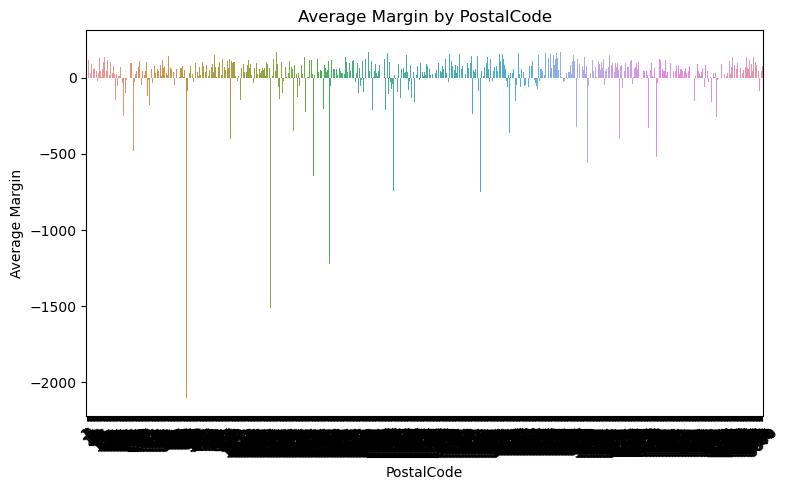

In [6]:
result3 = run_hypothesis_test(
    df=margin_df,
    test_name="Margin Difference Across Postal Codes",
    test_type="t-test",
    group_column="PostalCode",
    group_a=2000,
    group_b=122,
    outcome_column="Margin",
)
plot_margin(
    margin_df,
    "PostalCode",
)

## Hypothesis 4

### Null Hypothesis (H₀)

There is no significant difference in claim severity between Male and Female policyholders.

In [7]:
gender_data = claim_severity_df[
    claim_severity_df["Gender"].isin(["Male", "Female"])
]

result4 = run_hypothesis_test(
    df=gender_data,
    test_name="Risk Difference Between Male and Female",
    test_type="t-test",
    group_column="Gender",
    group_a="Male",
    group_b="Female",
    outcome_column="TotalClaims",
)

In [8]:
results_table = create_results_table(
    [
        result1,
        result2,
        result3,
        result4,
    ]
)

results_table

,Hypothesis,Test,P-Value,Decision
0,Risk Difference Across Provinces,Chi-Square,6.932050e-14,Reject H₀
1,Risk Difference Across Postal Codes,Chi-Square,5.788217e-02,Fail to Reject H₀
2,Margin Difference Across Postal Codes,Independent T-Test,2.444624e-01,Fail to Reject H₀
3,Risk Difference Between Male and Female,Independent T-Test,5.680287e-01,Fail to Reject H₀


# Business Recommendations

### Hypothesis 1: Risk Difference Across Provinces
The analysis found a statistically significant difference in claim frequency between Gauteng and Western Cape (p < 0.05). This suggests that geographic location influences insurance risk. The company should consider province-specific pricing or underwriting strategies rather than applying a uniform premium across all provinces.

### Hypothesis 2: Risk Difference Across Postal Codes
No statistically significant difference in claim frequency was found between Postal Codes 2000 and 122 (p > 0.05). Based on this comparison, there is insufficient evidence to justify different pricing solely based on these postal codes.

### Hypothesis 3: Margin Difference Across Postal Codes
The analysis did not find a significant difference in profit margin between the selected postal codes (p > 0.05). This indicates that the current pricing strategy produces similar profitability across these locations, although additional postal code comparisons could provide further insights.

### Hypothesis 4: Risk Difference Between Male and Female
No statistically significant difference in claim severity was observed between male and female policyholders (p > 0.05). Therefore, gender alone should not be considered a primary factor when adjusting insurance premiums for this dataset.